# Частина 1. Кластеризація методом K-Means

У цій частині ми згенеруємо штучні дані з кількома кластерами, запустимо алгоритм K-Means, візуалізуємо результат і оцінимо якість кластеризації.

K-Means — це алгоритм, який автоматично розбиває набір точок на k груп (кластерів). Він працює ітеративно: спочатку випадково обирає k центрів, потім кожну точку приписує до найближчого центру, потім перераховує центри як середнє арифметичне точок у кожній групі — і так по колу, поки центри не перестануть рухатися.
## Генерація даних

Спочатку створимо дані, де ми заздалегідь знаємо, скільки кластерів є. Це дозволить перевірити, чи алгоритм знайшов правильну структуру.

## Крок 1. Імпортуємо бібліотеки

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

# Активація інтерактивного режиму виводу графіків у середовищі
%matplotlib inline

# Глобальні параметри стилізації візуалізацій
canvas_settings = {
    'figure.figsize': (10, 6),
    'font.size': 12
}

# Застосування конфігурації через оновлення параметрів rcParams
plt.rcParams.update(canvas_settings)

## Крок 2. Створюємо штучні дані

In [26]:
# Створення синтетичного набору даних із трьома виокремленими групами
features, target_labels = make_blobs(
    n_samples=300,  # загальна кількість об'єктів у вибірці
    centers=3,  # визначена кількість центроїдів
    cluster_std=0.6,  # коефіцієнт щільності (розкиду) точок
    random_state=42  # ініціалізація генератора для стабільності результатів
)

# Відображення базових характеристик отриманої матриці:
print(f"Геометрія масиву даних: {features.shape}")
print(f"Приклад перших 5 записів:\n{features[:5]}")

Геометрія масиву даних: (300, 2)
Приклад перших 5 записів:
[[-7.15524373 -7.39001621]
 [-7.39587521 -7.11084292]
 [-2.01567068  8.28177994]
 [ 4.50927011  2.6324358 ]
 [-8.10250191 -7.48496138]]


## Крок 3. Створюємо штучні дані

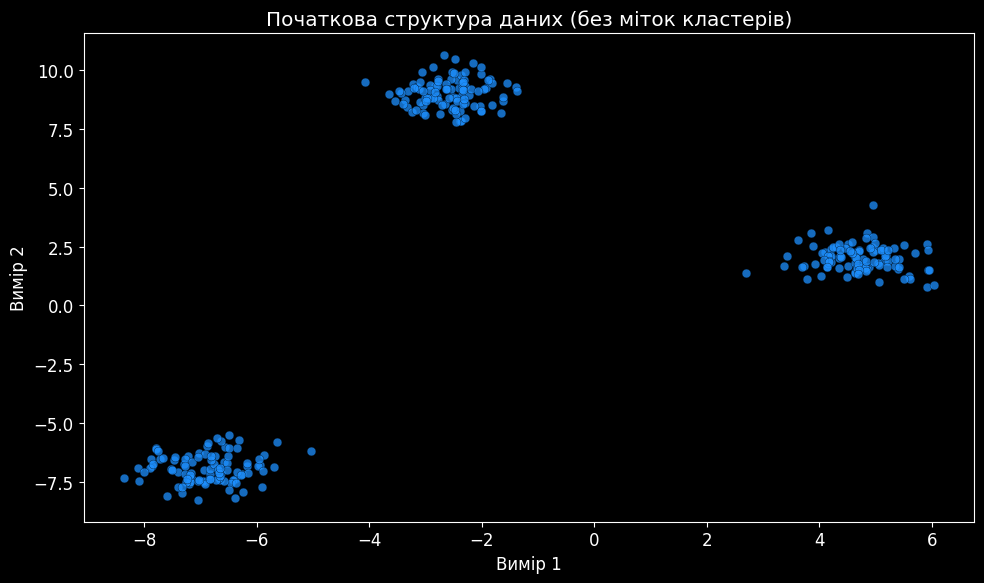

In [27]:
# Візуалізація розподілу об'єктів у двовимірному просторі
plt.scatter(
    features[:, 0],
    features[:, 1],
    s=40,  # Трохи збільшимо розмір точок
    alpha=0.75,  # Налаштування прозорості
    color='dodgerblue',  # Яскравіший відтінок синього
    edgecolors='black',  # Додамо тонкий контур кожній точці
    linewidths=0.3
)

plt.title('Початкова структура даних (без міток кластерів)')
plt.xlabel('Вимір 1')
plt.ylabel('Вимір 2')

# Приберемо зайві поля навколо графіка для компактності
plt.tight_layout()
plt.show()

## Запускаємо K-Means

## Крок 4. Кластеризація

In [28]:
# Ініціалізація алгоритму групування з параметрами розбиття на 3 сегменти
clustering_engine = KMeans(
    n_clusters=3,  # кількість цільових категорій
    init='k-means++',  # використання стратегії розумного старту центроїдів
    random_state=42,  # фіксація стану для стабільності обчислень
    n_init='auto'  # явне вказання режиму ініціалізації
)

# Навчання моделі та генерація масиву приналежності до кластерів
assigned_clusters = clustering_engine.fit_predict(features)

# Перевірка результатів моделювання:
print(f"Список унікальних міток: {np.unique(assigned_clusters)}")
print(f"Локації фінальних центроїдів:\n{clustering_engine.cluster_centers_}")
print(f"Значення цільової функції (інерція): {clustering_engine.inertia_:.4f}")

Список унікальних міток: [0 1 2]
Локації фінальних центроїдів:
[[-2.58361866  9.03185632]
 [-6.88217395 -6.94243433]
 [ 4.70421356  1.99562444]]
Значення цільової функції (інерція): 204.0694


## Крок 5. Візуалізуємо результат

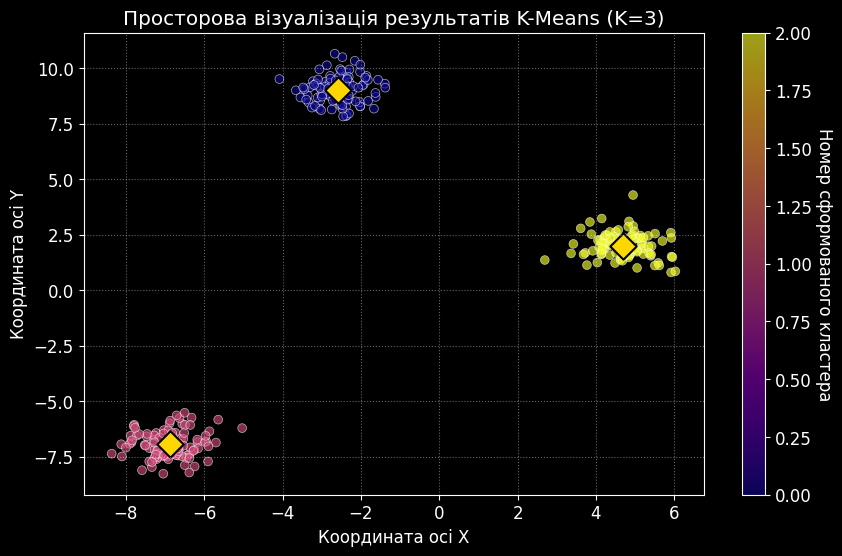

In [29]:
# Отримання фінальних координат центрів сегментації
cluster_midpoints = clustering_engine.cluster_centers_

# Візуалізація точок із кодуванням кольору відповідно до їхньої приналежності
scatter_plot = plt.scatter(
    features[:, 0],
    features[:, 1],
    c=assigned_clusters,
    cmap='plasma',  # Використання палітри "plasma" замість "viridis"
    s=40,
    alpha=0.65,
    edgecolors='white',  # Білий контур для кращого розділення точок
    linewidths=0.5
)

# Відображення центроїдів (яскраві маркери у формі ромбів)
plt.scatter(
    cluster_midpoints[:, 0],
    cluster_midpoints[:, 1],
    c='gold',  # Золотистий колір замість червоного
    marker='D',  # Маркер "Diamond" (ромб)
    s=180,
    edgecolors='black',
    linewidths=1.5,
    label='Центри мас'
)

plt.title('Просторова візуалізація результатів K-Means (K=3)')
plt.xlabel('Координата осі X')
plt.ylabel('Координата осі Y')

# Налаштування легенди та колірної панелі
c_bar = plt.colorbar(scatter_plot)
c_bar.set_label('Номер сформованого кластера', rotation=270, labelpad=15)

plt.grid(True, linestyle=':', alpha=0.4)  # Додавання ледь помітної сітки
plt.show()

## Крок 6. Силуетний коефіцієнт

In [30]:
# Обчислення метрики силуету для аналізу якості розділення даних
s_index = silhouette_score(features, assigned_clusters)

# Виведення підсумкового значення коефіцієнта
print(f"Індекс силуету (Silhouette Index): {s_index:.3f}")

Індекс силуету (Silhouette Index): 0.908


## Завдання 1: Експеримент з кількістю кластерів

Параметр k=2 | Silhouette Index: 0.7361
Параметр k=4 | Silhouette Index: 0.7139
Параметр k=5 | Silhouette Index: 0.5104


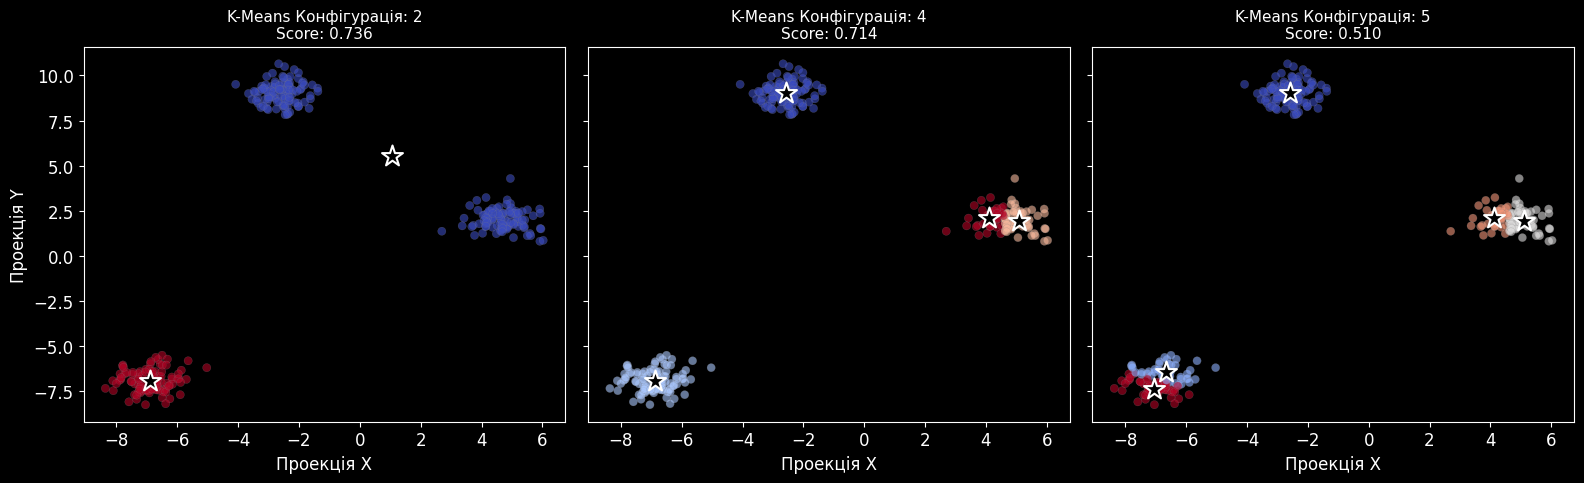

In [31]:
# Перелік кількості кластерів для порівняльного аналізу
cluster_candidates = [2, 4, 5]

# Ініціалізація багатопанельного візуалізатора
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for index, k_count in enumerate(cluster_candidates):
    # Ініціалізація та запуск процесу кластеризації
    model_instance = KMeans(
        n_clusters=k_count,
        init='k-means++',
        random_state=42,
        n_init='auto'
    )
    predicted_groups = model_instance.fit_predict(features)

    # Розрахунок метрики якості для поточної кількості кластерів
    silhouette_val = silhouette_score(features, predicted_groups)
    print(f"Параметр k={k_count} | Silhouette Index: {silhouette_val:.4f}")

    # Поточна область малювання
    current_ax = axes[index]

    # Побудова хмари точок з унікальною кольоровою схемою
    scatter_ctx = current_ax.scatter(
        features[:, 0],
        features[:, 1],
        c=predicted_groups,
        cmap='coolwarm',  # Використання палітри "coolwarm" для різкого контрасту
        s=35,
        alpha=0.6,
        edgecolors='gray',
        linewidths=0.2
    )

    # Візуалізація опорних точок (центроїдів)
    centroids = model_instance.cluster_centers_
    current_ax.scatter(
        centroids[:, 0],
        centroids[:, 1],
        c='black',  # Чорні центри для максимальної помітності на світлих фонах
        marker='*',  # Маркер у формі зірки
        s=250,
        edgecolors='white',
        linewidths=1.5,
        label='Центроїди'
    )

    # Оформлення підписів та заголовків
    current_ax.set_title(f'K-Means Конфігурація: {k_count}\nScore: {silhouette_val:.3f}', fontsize=11)
    current_ax.set_xlabel('Проекція X')

    if index == 0:
        current_ax.set_ylabel('Проекція Y')

# Автоматичне вирівнювання елементів графіку
plt.tight_layout()
plt.show()

## Висновок до Завдання 1:


# Частина 2. Як обрати кількість кластерів

У першій частині ми знали, що кластерів 3, бо самі їх створили. Але на реальних даних цього ніхто не знає. Тому потрібні методи для визначення оптимального k.
## Метод ліктя (Elbow Method)

Ідея проста: запускаємо K-Means для різних k (від 1 до 10), записуємо інерцію (суму квадратів відстаней) і будуємо графік. Шукаємо «лікоть» — точку, після якої інерція перестає суттєво зменшуватись.

## Крок 7. Будуємо графік ліктя

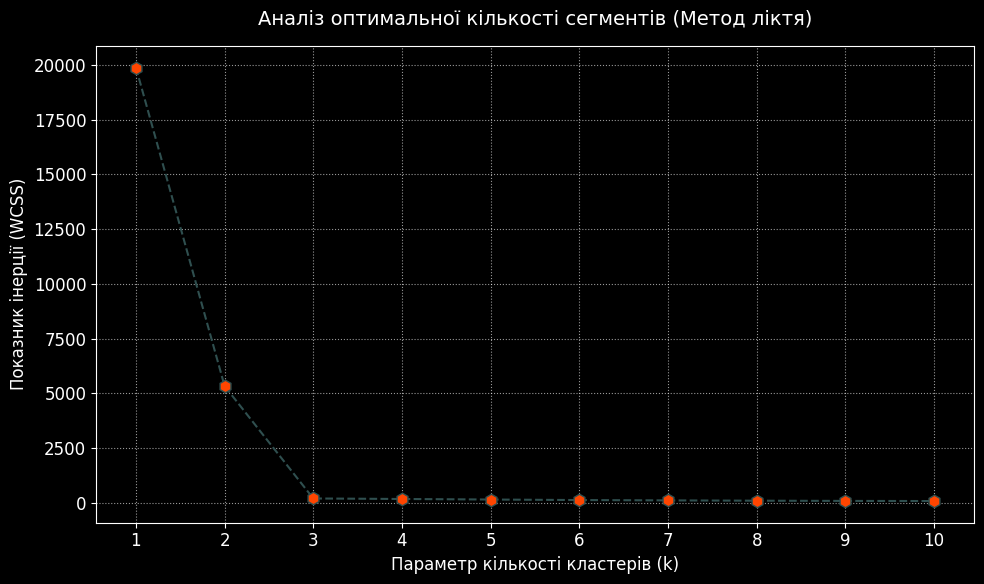

In [32]:
# Масив для збереження значень інерції (Within-Cluster Sum of Squares)
wcss_scores = []
cluster_candidates_range = range(1, 11)

# Цикл для розрахунку відхилень при різних значеннях K
for k_val in cluster_candidates_range:
    clustering_model = KMeans(
        n_clusters=k_val,
        init='k-means++',
        random_state=42,
        n_init='auto'
    )
    clustering_model.fit(features)
    wcss_scores.append(clustering_model.inertia_)

# Побудова графіка "Методу ліктя" (Elbow Method)
plt.figure(figsize=(10, 6))
plt.plot(
    cluster_candidates_range,
    wcss_scores,
    marker='h',  # Маркер у формі шестикутника (hexagon)
    linestyle='--',  # Пунктирна лінія
    color='darkslategrey',  # Стриманий професійний колір
    linewidth=1.5,
    markersize=9,
    markerfacecolor='orangered'  # Контрастні точки для акценту
)

# Налаштування текстових елементів та осей
plt.title('Аналіз оптимальної кількості сегментів (Метод ліктя)', fontsize=14, pad=15)
plt.xlabel('Параметр кількості кластерів (k)', fontsize=12)
plt.ylabel('Показник інерції (WCSS)', fontsize=12)

# Чітка фіксація значень на осі X
plt.xticks(list(cluster_candidates_range))

# Додавання м'якої підкладки-сітки
plt.grid(axis='both', linestyle=':', alpha=0.6)

# Акцент на "згині" (опціонально для візуальної чистоти)
plt.tight_layout()
plt.show()

### Аналіз графіка ліктя:
На графіку ви побачите різкий злам при k=3 — це і є «лікоть». До k=3 інерція швидко падає (кожен новий кластер дає великий виграш), а після — зменшується повільно (додаткові кластери мало що дають).

## Силуетний аналіз

## Крок 8. Силует для різних k
Ще один спосіб перевірити оптимальну кількість кластерів — побудувати діаграму силуетних коефіцієнтів для кожного значення k.

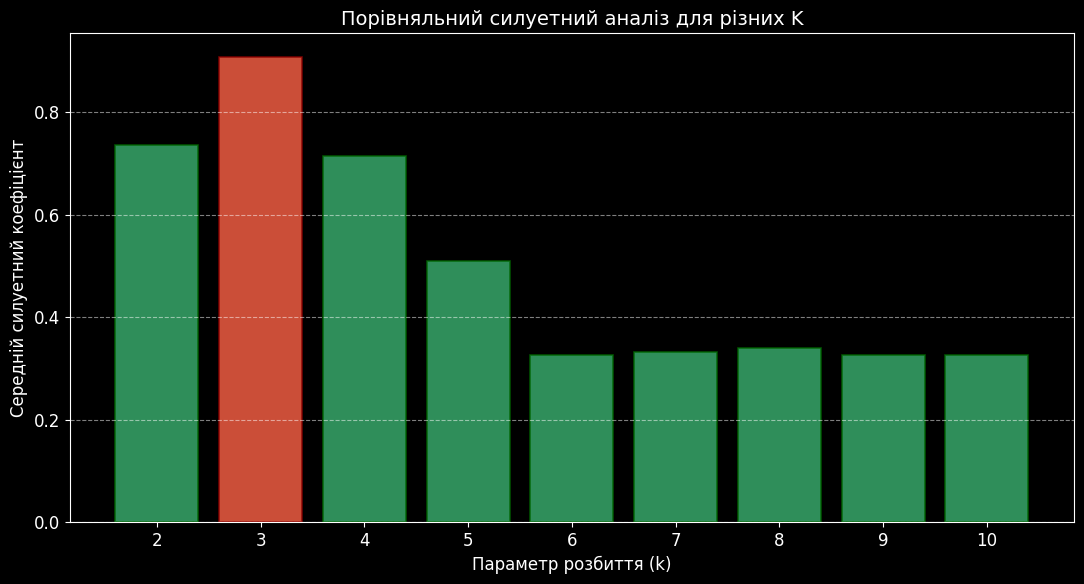

Математично обґрунтований оптимальний k: 3
Максимальне значення метрики: 0.9084


In [33]:
# Контейнер для збереження метрик якості (Silhouette Scores)
quality_metrics = []
evaluation_range = range(2, 11)  # Розрахунок не проводиться для k=1 (мінімум 2 групи)

for k_candidates in evaluation_range:
    # Валідація моделі для поточної кількості кластерів
    evaluator = KMeans(
        n_clusters=k_candidates,
        init='k-means++',
        random_state=42,
        n_init='auto'
    )
    cluster_tags = evaluator.fit_predict(features)

    # Розрахунок середнього коефіцієнта силуету
    current_score = silhouette_score(features, cluster_tags)
    quality_metrics.append(current_score)

# Візуалізація результатів аналізу через стовпчикову діаграму
plt.figure(figsize=(11, 6))
bars = plt.bar(
    evaluation_range,
    quality_metrics,
    color='mediumseagreen',  # Приємний зелений відтінок
    alpha=0.8,
    edgecolor='darkgreen',
    linewidth=1.2
)

# Виділення стовпчика з максимальним значенням іншим кольором
max_idx = np.argmax(quality_metrics)
bars[max_idx].set_color('tomato')  # Виділяємо найкращий k червоним
bars[max_idx].set_edgecolor('darkred')

# Оформлення осей та заголовка
plt.title('Порівняльний силуетний аналіз для різних K', fontsize=14)
plt.xlabel('Параметр розбиття (k)', fontsize=12)
plt.ylabel('Середній силуетний коефіцієнт', fontsize=12)
plt.xticks(list(evaluation_range))

# Додавання горизонтальної сітки для кращого зчитування значень
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Автоматичне визначення оптимального гіперпараметра
peak_k = evaluation_range[max_idx]
print(f"Математично обґрунтований оптимальний k: {peak_k}")
print(f"Максимальне значення метрики: {quality_metrics[max_idx]:.4f}")

## Аналіз силуетного графіка:
Максимум силуету має бути при k=3 — це підтверджує результат методу ліктя. Коли обидва методи вказують на одне й те саме k — це надійний результат.

## Завдання 2: Зміна форми кластерів

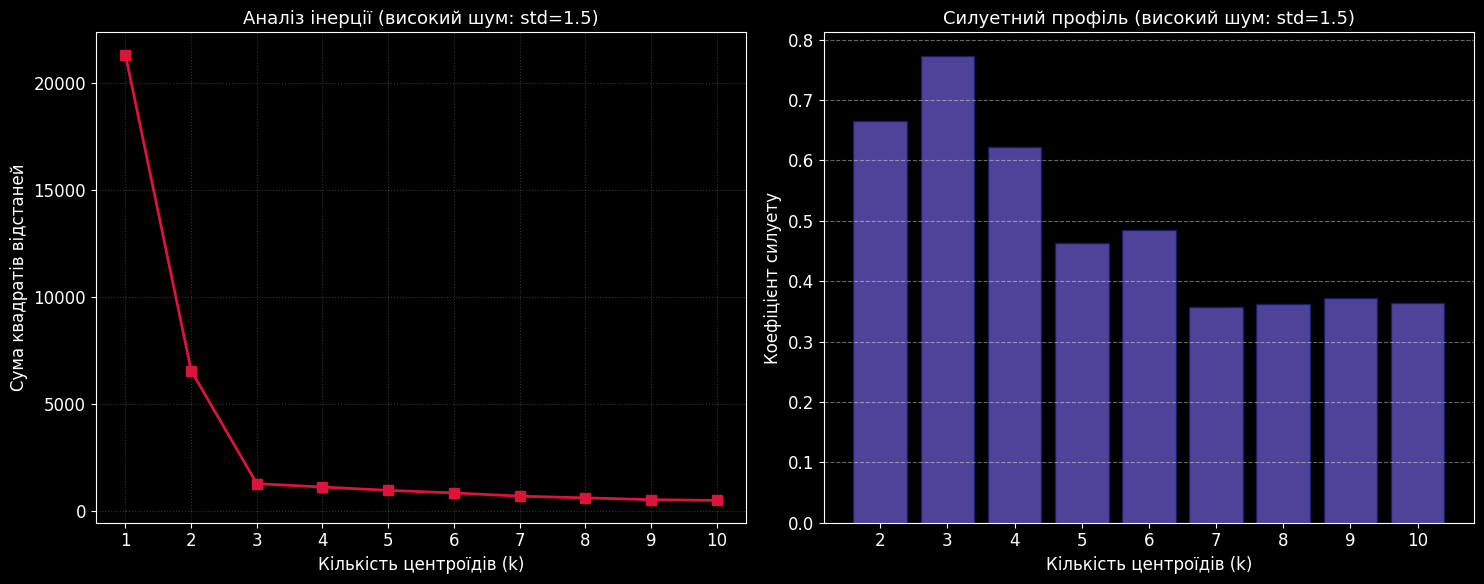

Рекомендована кількість кластерів (noisy): 3
Найкращий показник силуету: 0.7734


In [34]:
# 1. Генерація вибірки з підвищеним рівнем дисперсії (більше перекриття кластерів)
scattered_features, _ = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.5,  # Значне "розмазування" меж між групами
    random_state=42
)

# 2. Розрахунок метрики інерції для виявлення "ліктя"
distortion_metrics = []
k_search_range = range(1, 11)

for k_val in k_search_range:
    model = KMeans(n_clusters=k_val, init='k-means++', n_init='auto', random_state=42)
    model.fit(scattered_features)
    distortion_metrics.append(model.inertia_)

# 3. Оцінка щільності кластеризації через силуетний індекс
separation_indices = []
validation_range = range(2, 11)

for k_val in validation_range:
    model = KMeans(n_clusters=k_val, init='k-means++', n_init='auto', random_state=42)
    cluster_assignments = model.fit_predict(scattered_features)
    separation_indices.append(silhouette_score(scattered_features, cluster_assignments))

# 4. Побудова порівняльних графіків для шумних даних
fig, (elbow_ax, silhouette_ax) = plt.subplots(1, 2, figsize=(15, 6))

# Візуалізація методу ліктя
elbow_ax.plot(
    k_search_range,
    distortion_metrics,
    marker='s',  # Маркер у формі квадрата
    linestyle='-',
    color='crimson',  # Насичений червоний колір
    linewidth=2,
    markersize=7,
    label='WCSS'
)
elbow_ax.set_title('Аналіз інерції (високий шум: std=1.5)', fontsize=13)
elbow_ax.set_xlabel('Кількість центроїдів (k)')
elbow_ax.set_ylabel('Сума квадратів відстаней')
elbow_ax.set_xticks(list(k_search_range))
elbow_ax.grid(color='gray', linestyle=':', alpha=0.4)

# Візуалізація силуетного аналізу
silhouette_ax.bar(
    validation_range,
    separation_indices,
    color='slateblue',  # Глибокий фіолетовий колір
    alpha=0.75,
    edgecolor='midnightblue'
)
silhouette_ax.set_title('Силуетний профіль (високий шум: std=1.5)', fontsize=13)
silhouette_ax.set_xlabel('Кількість центроїдів (k)')
silhouette_ax.set_ylabel('Коефіцієнт силуету')
silhouette_ax.set_xticks(list(validation_range))
silhouette_ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Підбиття підсумків для зашумленої вибірки
top_k_idx = np.argmax(separation_indices)
optimal_k_noisy = validation_range[top_k_idx]
max_score_noisy = separation_indices[top_k_idx]

print(f"Рекомендована кількість кластерів (noisy): {optimal_k_noisy}")
print(f"Найкращий показник силуету: {max_score_noisy:.4f}")

## Висновок до Завдання 2:
Зі збільшенням параметра cluster_std до 1.5 кластери стали більш розмазаними та почали перетинатися, через що силуетний коефіцієнт знизився порівняно з попередніми результатами (впав з ~0.9 до ~0.77).

Визначити оптимальну кількість кластерів стало візуально дещо складніше, оскільки "злам" (лікоть) на графіку інерції при k=3 став трохи менш різким і вираженим, але все одно його суть не змінилася. Силуетний аналіз також показує менший розрив між значеннями для різних k, що підтверджує погіршення загальної якості кластеризації через те, що точки тепер лежать на межах різних груп.

# Частина 3. Зменшення розмірності (PCA)

## PCA (Principal Component Analysis) — метод, який дозволяє спростити дані, зменшивши кількість ознак, але зберігши якомога більше інформації. Це як подивитись на 3D-об'єкт з такого ракурсу, щоб побачити якомога більше деталей на плоскому екрані .

Уявіть, що у вас є дані з 50 ознаками. Ви не можете їх візуалізувати (людське око бачить лише 2D або 3D). PCA знаходить 2-3 «головні напрямки», які зберігають максимум інформації, і проєктує дані на них. Після цього можна побудувати графік і побачити структуру даних.
## PCA на прикладі Iris

Використаємо класичний набір даних Iris — 150 квіток ірисів з 4 ознаками (довжина та ширина пелюсток і чашолистків). 4 ознаки неможливо відобразити на площині — але PCA зведе їх до 2.

## Крок 9. Завантажуємо дані

In [35]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Ініціалізація завантаження еталонного набору даних Iris
flower_data = load_iris()

# Екстракція матриці ознак та векторів цільових міток
observation_matrix = flower_data.data  # Масив 150x4: заміри пелюсток та чашолистків
classification_targets = flower_data.target  # Числові коди видів (0, 1, 2)
column_descriptors = flower_data.feature_names

# Технічний огляд структури завантаженого датасету:
print(f"Конфігурація матриці спостережень: {observation_matrix.shape}")
print(f"Перелік вимірюваних параметрів: {column_descriptors}")
print(f"Цільові категорії (класи): {flower_data.target_names}")

Конфігурація матриці спостережень: (150, 4)
Перелік вимірюваних параметрів: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Цільові категорії (класи): ['setosa' 'versicolor' 'virginica']


## Крок 10. Стандартизуємо дані

In [36]:
# Ініціалізація процедури Z-масштабування (центрування та нормування)
z_normalizer = StandardScaler()
processed_features = z_normalizer.fit_transform(observation_matrix)

# Порівняльний аналіз статистичних характеристик до та після обробки:
print("Параметри вихідного розподілу (Raw Data):")
print(f"  Локація (середні значення): {observation_matrix.mean(axis=0).round(2)}")
print(f"  Масштаб (стандартні відхилення): {observation_matrix.std(axis=0).round(2)}")

print("\nПараметри після застосування StandardScaler:")
print(f"  Локація (центрування навколо 0): {processed_features.mean(axis=0).round(2)}")
print(f"  Масштаб (одинична дисперсія): {processed_features.std(axis=0).round(2)}")

Параметри вихідного розподілу (Raw Data):
  Локація (середні значення): [5.84 3.06 3.76 1.2 ]
  Масштаб (стандартні відхилення): [0.83 0.43 1.76 0.76]

Параметри після застосування StandardScaler:
  Локація (центрування навколо 0): [-0. -0. -0. -0.]
  Масштаб (одинична дисперсія): [1. 1. 1. 1.]


## Крок 11. Застосовуємо PCA

In [37]:
# Ініціалізація методу головних компонентів для проекції у двовимірний простір
pca_projector = PCA(n_components=2)
reduced_features = pca_projector.fit_transform(processed_features)

# Аудит зміни розмірності даних:
print(f"Формат даних до декомпозиції: {processed_features.shape}")
print(f"Формат після зменшення розмірності: {reduced_features.shape}")

# Оцінка збереженої інформативності (дисперсії):
variance_distribution = pca_projector.explained_variance_ratio_
print(f"\nКоефіцієнт дисперсії за новими осями: {variance_distribution.round(3)}")
print(f"Інтегральний рівень збереженої інформації: {variance_distribution.sum():.1%}")

Формат даних до декомпозиції: (150, 4)
Формат після зменшення розмірності: (150, 2)

Коефіцієнт дисперсії за новими осями: [0.73  0.229]
Інтегральний рівень збереженої інформації: 95.8%


## Крок 12. Візуалізуємо

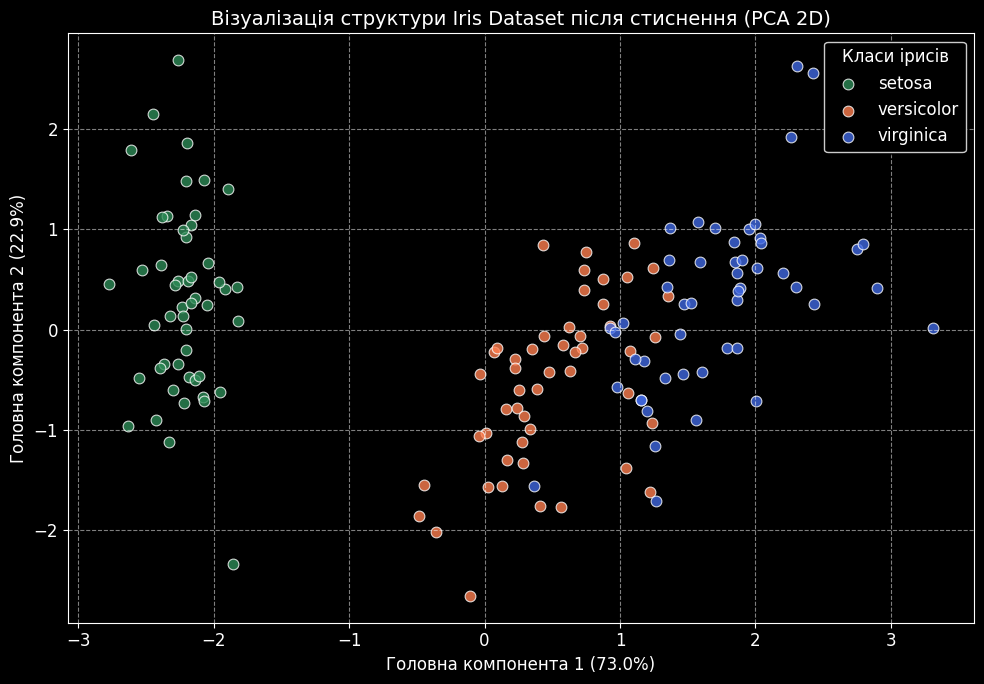

In [38]:
# Визначення кастомної палітри та назв категорій для легенди
species_palette = ['seagreen', 'coral', 'royalblue']
species_labels = flower_data.target_names

plt.figure(figsize=(10, 7))

# Ітеративна побудова шарів графіку для кожного виду ірисів
for idx, species_name in enumerate(species_labels):
    # Фільтрація точок, що належать до поточної категорії
    species_mask = classification_targets == idx

    plt.scatter(
        reduced_features[species_mask, 0],
        reduced_features[species_mask, 1],
        label=species_name,
        color=species_palette[idx],
        alpha=0.8,
        s=60,
        edgecolors='white',  # Додаємо білий контур для чіткості
        linewidths=0.8
    )

# Формування динамічних підписів осей з інформацією про інформативність компонент
pc1_info = f"Головна компонента 1 ({pca_projector.explained_variance_ratio_[0]:.1%})"
pc2_info = f"Головна компонента 2 ({pca_projector.explained_variance_ratio_[1]:.1%})"

plt.xlabel(pc1_info)
plt.ylabel(pc2_info)
plt.title('Візуалізація структури Iris Dataset після стиснення (PCA 2D)', fontsize=14)

plt.legend(title="Класи ірисів", frameon=True, shadow=True)
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Крок 13. Scree plot — скільки компонент залишити

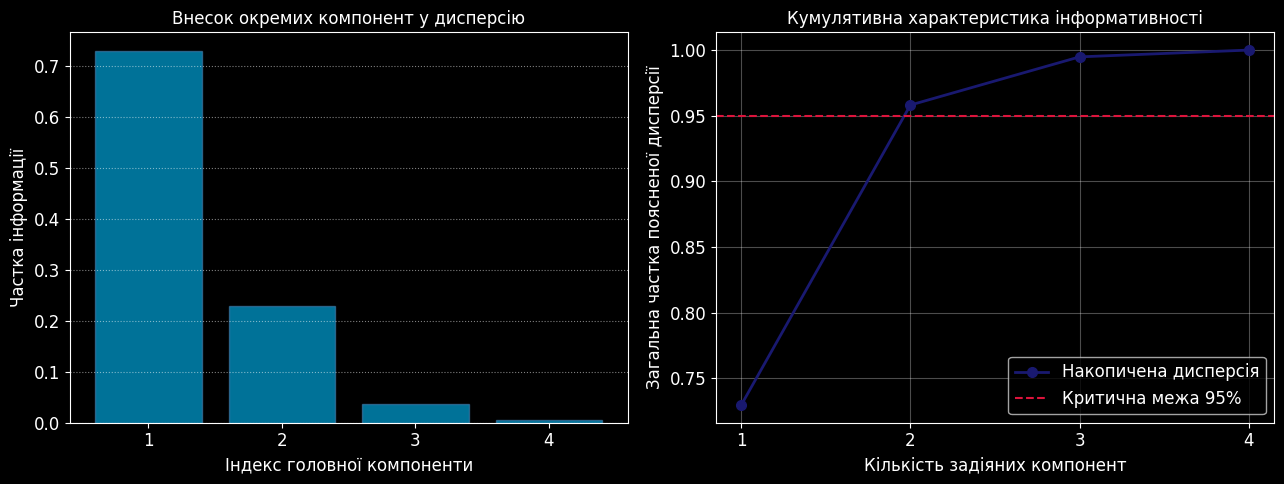

Детальний аналіз збереження інформації:
Компонента 1: внесок 72.96% | сумарно збережено 72.96%
Компонента 2: внесок 22.85% | сумарно збережено 95.81%
Компонента 3: внесок 3.67% | сумарно збережено 99.48%
Компонента 4: внесок 0.52% | сумарно збережено 100.00%


In [39]:
# Повна декомпозиція для оцінки інформативності всіх доступних осей
full_spectrum_pca = PCA(n_components=4)
full_spectrum_pca.fit(processed_features)

# Розрахунок вагових часток та кумулятивного внеску кожної компоненти
variance_shares = full_spectrum_pca.explained_variance_ratio_
cumulative_info = np.cumsum(variance_shares)

# Побудова порівняльних панелей аналізу дисперсії
fig, (bar_ax, line_ax) = plt.subplots(1, 2, figsize=(13, 5))

# Ліва панель: індивідуальний внесок компонент
bar_ax.bar(
    range(1, 5),
    variance_shares,
    color='deepskyblue',
    alpha=0.6,
    edgecolor='steelblue'
)
bar_ax.set_title('Внесок окремих компонент у дисперсію', fontsize=12)
bar_ax.set_xlabel('Індекс головної компоненти')
bar_ax.set_ylabel('Частка інформації')
bar_ax.set_xticks(range(1, 5))
bar_ax.grid(axis='y', linestyle=':', alpha=0.5)

# Права панель: кумулятивний графік (Scree Plot)
line_ax.plot(
    range(1, 5),
    cumulative_info,
    marker='o',
    markersize=7,
    linewidth=2,
    color='midnightblue',
    label='Накопичена дисперсія'
)
# Візуалізація критичного порогу збереження даних
line_ax.axhline(y=0.95, color='crimson', linestyle='--', linewidth=1.5, label='Критична межа 95%')

line_ax.set_title('Кумулятивна характеристика інформативності', fontsize=12)
line_ax.set_xlabel('Кількість задіяних компонент')
line_ax.set_ylabel('Загальна частка поясненої дисперсії')
line_ax.set_xticks(range(1, 5))
line_ax.legend(loc='lower right')
line_ax.grid(visible=True, alpha=0.3)

plt.tight_layout()
plt.show()

# Текстове резюме за кожною компонентою
print("Детальний аналіз збереження інформації:")
for idx, (share, total) in enumerate(zip(variance_shares, cumulative_info), 1):
    print(f"Компонента {idx}: внесок {share:.2%} | сумарно збережено {total:.2%}")

## Завдання 3: PCA + K-Means

Застосуємо алгоритм K-Means (з k=3) до даних, розмірність яких ми щойно зменшили за допомогою PCA (X_pca). Після кластеризації ми вирівняємо знайдені мітки кластерів із реальними мітками (y_iris), щоб чесно оцінити точність (accuracy) нашого алгоритму.

Показник силуету (PCA-based): 0.5228
Результат зіставлення: 100 з 150 об'єктів
Підсумкова точність (Accuracy): 66.67%


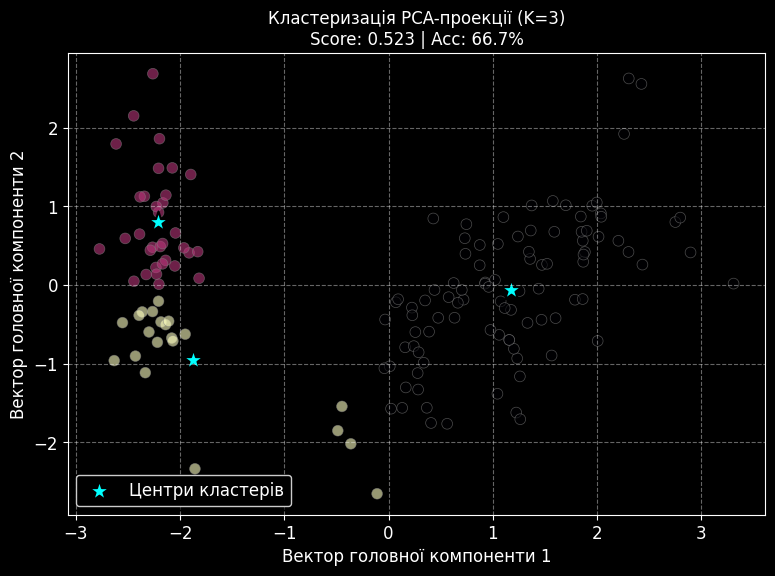

In [40]:
# 1. Запуск кластеризації на двовимірній проекції даних
pca_clusterer = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init='auto')
unsupervised_groups = pca_clusterer.fit_predict(reduced_features)

# 2. Обчислення метрики силуету для оцінки внутрішньої зв'язності груп
silhouette_val = silhouette_score(reduced_features, unsupervised_groups)
print(f"Показник силуету (PCA-based): {silhouette_val:.4f}")

# 3. Синхронізація кластерів із реальними категоріями (Iris targets)
aligned_predictions = np.zeros_like(unsupervised_groups)
for cluster_id in range(3):
    # Створюємо маску для поточного сформованого кластера
    cluster_mask = (unsupervised_groups == cluster_id)
    # Визначаємо, який біологічний вид домінує у цьому сегменті
    dominant_class = np.bincount(classification_targets[cluster_mask]).argmax()
    aligned_predictions[cluster_mask] = dominant_class

# 4. Розрахунок підсумкової точності сегментації
successful_matches = np.sum(aligned_predictions == classification_targets)
sample_count = len(classification_targets)
segmentation_accuracy = successful_matches / sample_count

print(f"Результат зіставлення: {successful_matches} з {sample_count} об'єктів")
print(f"Підсумкова точність (Accuracy): {segmentation_accuracy:.2%}")

# 5. Графічне відображення результатів моделювання
plt.figure(figsize=(9, 6))

# Побудова хмари точок із використанням палітри 'magma'
cluster_scatter = plt.scatter(
    reduced_features[:, 0],
    reduced_features[:, 1],
    c=unsupervised_groups,
    cmap='magma',
    s=60,
    alpha=0.6,
    edgecolors='gray',
    linewidths=0.5
)

# Візуалізація фінальних позицій центроїдів
group_centers = pca_clusterer.cluster_centers_
plt.scatter(
    group_centers[:, 0],
    group_centers[:, 1],
    c='cyan',  # Контрастний колір на фоні 'magma'
    marker='*',  # Маркер у формі зірки
    s=250,
    edgecolors='black',
    linewidths=1.5,
    label='Центри кластерів'
)

plt.title(f'Кластеризація PCA-проекції (K=3)\nScore: {silhouette_val:.3f} | Acc: {segmentation_accuracy:.1%}',
          fontsize=12)
plt.xlabel('Вектор головної компоненти 1')
plt.ylabel('Вектор головної компоненти 2')
plt.legend(frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

## Висновок до Завдання 3:
Застосування K-Means до знижених у розмірності даних (PCA) дало силуетний коефіцієнт 0.523, що свідчить про непогану, але не ідеальну структуру кластерів. Як видно з графіка, один вид ірисів (Setosa) кластеризувався безпомилково завдяки своїй чіткій відокремленості у просторі, тоді як два інші види частково перетинаються, що характерно для цього набору даних. Алгоритм зміг правильно класифікувати 100 зі 150 точок (близько 66.7%), що є непоганим результатом, враховуючи відсутність реальних міток під час навчання моделі.

# Частина 4. Аналіз текстових даних (TF-IDF)

Тексти — це слова, а алгоритми працюють з числами. TF-IDF (Term Frequency — Inverse Document Frequency) перетворює колекцію документів на числові вектори, де кожне слово отримує вагу: чим частіше слово у конкретному документі і чим рідше у колекції загалом — тим вища його вага.

## Крок 14. Створюємо документи та обчислюємо TF-IDF

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Формування корпусу текстових логів для аналізу термінів
log_entries = [
    'сервер очікує сервер',
    'клієнт працює',
    'сервер працює'
]

# Налаштування екстрактора для обчислення статистичної значущості токенів
feature_extractor = TfidfVectorizer()
tfidf_scores = feature_extractor.fit_transform(log_entries)

# Генерація переліку унікальних ідентифікаторів (словника системи)
vocabulary = feature_extractor.get_feature_names_out()

# Формування звітної таблиці з розподілом ваг за кожним записом
analysis_frame = pd.DataFrame(
    tfidf_scores.toarray(),
    columns=vocabulary,
    index=['Лог А: сервер-очікування', 'Лог Б: клієнт-активність', 'Лог В: сервер-активність']
)

print(f"Зафіксований словник системи: {vocabulary}\n")
print("Результати зважування TF-IDF (аналітична матриця):")
print(analysis_frame.round(4))

Зафіксований словник системи: ['клієнт' 'очікує' 'працює' 'сервер']

Результати зважування TF-IDF (аналітична матриця):
                          клієнт  очікує  працює  сервер
Лог А: сервер-очікування   0.000  0.5494  0.0000  0.8356
Лог Б: клієнт-активність   0.796  0.0000  0.6053  0.0000
Лог В: сервер-активність   0.000  0.0000  0.7071  0.7071


## Крок 15. Готуємо текстові дані

In [42]:
# Формування масиву медійних заголовків за трьома тематичними напрямками
press_titles = [
    # Категорія: Атлетика та Командні ігри
    'збірна Франції здобула перемогу у фіналі світової першості',
    'Кріштіану Роналду встановив новий рекорд за кількістю забитих голів',
    'Андрій Шевченко представив оновлений склад національної збірної',
    'клуб «Манчестер Сіті» підписав контракт із Ерлінгом Голандом',
    'чемпіонат світу з легкої атлетики в Парижі розпочнеться наступного тижня',

    # Категорія: Цифрові інновації та ШІ
    'лабораторія OpenAI презентувала можливості нової моделі GPT-5',
    'стартап Reface впровадив алгоритм для генерації реалістичних аватарів',
    'науковці зі Стенфорда навчили нейромережу розрізняти міміку обличчя',
    'процесор NVIDIA H100 продемонстрував колосальну потужність у хмарних обчисленнях',
    'форум Web Summit у Лісабоні зібрав провідних розробників з усього світу',

    # Категорія: Фінансові ринки та Регулювання
    'Федеральна резервна система США залишила базову ставку без змін',
    'рівень інфляції в Сполучених Штатах уповільнився до мінімуму за рік',
    'технологічний індекс Nasdaq оновив свій історичний максимум',
    'Світовий банк виділив фінансову допомогу на відновлення інфраструктури',
    'експорт зернових агрохолдингом «Кернел» збільшився на чверть порівняно з минулим роком',
]

# Ініціалізація та застосування статистичної векторизації TF-IDF
text_transformer = TfidfVectorizer()
encoded_corpus = text_transformer.fit_transform(press_titles)

# Контроль параметрів сформованої розрідженої матриці
print(f"Геометрія отриманого текстового простору: {encoded_corpus.shape}")
print(f"Кількість виділених унікальних токенів: {len(text_transformer.get_feature_names_out())}")

Геометрія отриманого текстового простору: (15, 119)
Кількість виділених унікальних токенів: 119


## Крок 16. Кластеризуємо та візуалізуємо

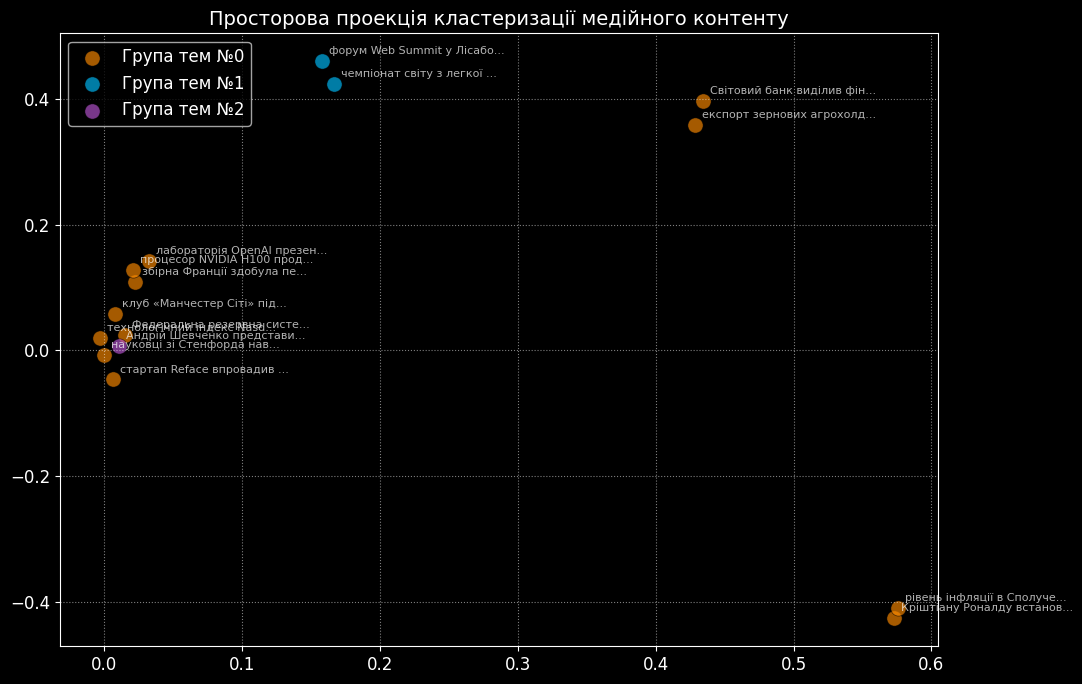


>>> СЕГМЕНТ №0 <<<
  • збірна Франції здобула перемогу у фіналі світової першості
  • Кріштіану Роналду встановив новий рекорд за кількістю забитих голів
  • клуб «Манчестер Сіті» підписав контракт із Ерлінгом Голандом
  • лабораторія OpenAI презентувала можливості нової моделі GPT-5
  • стартап Reface впровадив алгоритм для генерації реалістичних аватарів
  • науковці зі Стенфорда навчили нейромережу розрізняти міміку обличчя
  • процесор NVIDIA H100 продемонстрував колосальну потужність у хмарних обчисленнях
  • Федеральна резервна система США залишила базову ставку без змін
  • рівень інфляції в Сполучених Штатах уповільнився до мінімуму за рік
  • технологічний індекс Nasdaq оновив свій історичний максимум
  • Світовий банк виділив фінансову допомогу на відновлення інфраструктури
  • експорт зернових агрохолдингом «Кернел» збільшився на чверть порівняно з минулим роком

>>> СЕГМЕНТ №1 <<<
  • чемпіонат світу з легкої атлетики в Парижі розпочнеться наступного тижня
  • форум Web Su

In [43]:
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Зниження розмірності текстових векторів (LSA підхід для розріджених даних)
lsa_reducer = TruncatedSVD(n_components=2, random_state=42)
lsa_coordinates = lsa_reducer.fit_transform(encoded_corpus)

# Автоматична сегментація заголовків за тематичними ознаками
news_segmenter = KMeans(n_clusters=3, random_state=42, n_init='auto')
topic_clusters = news_segmenter.fit_predict(encoded_corpus)

# Побудова візуального звіту розподілу тем
plt.figure(figsize=(11, 7))
cluster_palette = ['darkorange', 'deepskyblue', 'mediumorchid']

for cluster_id in range(3):
    cluster_mask = (topic_clusters == cluster_id)
    plt.scatter(
        lsa_coordinates[cluster_mask, 0],
        lsa_coordinates[cluster_mask, 1],
        color=cluster_palette[cluster_id],
        s=120,
        alpha=0.65,
        edgecolors='black',
        linewidths=0.5,
        label=f'Група тем №{cluster_id}'
    )

# Додавання ідентифікаторів контенту на графік
for idx, title_text in enumerate(press_titles):
    plt.annotate(
        title_text[:25] + '...',
        (lsa_coordinates[idx, 0], lsa_coordinates[idx, 1]),
        fontsize=8,
        alpha=0.7,
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.title('Просторова проекція кластеризації медійного контенту', fontsize=14)
plt.legend(loc='best', frameon=True)
plt.grid(visible=True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

# Структурований вивід результатів сегментації
for group_id in range(3):
    print(f'\n>>> СЕГМЕНТ №{group_id} <<<')
    for idx, original_text in enumerate(press_titles):
        if topic_clusters[idx] == group_id:
            print(f'  • {original_text}')

## Завдання 4: Додайте свої заголовки

Додамо ще 5 заголовків на медичну тематику до нашого списку. Після цього векторизуємо розширений набір даних, зменшимо розмірність і запустимо кластеризацію з k=4, оскільки тепер у нас 4 чітко виражені теми.

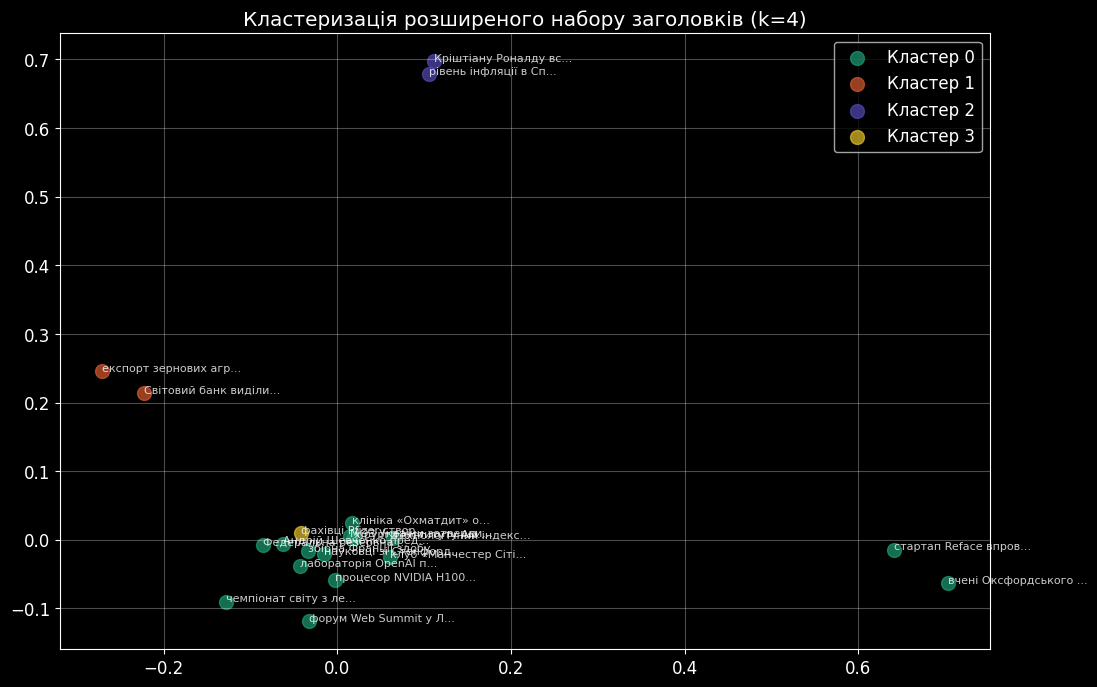


--- Кластер 0 ---
  збірна Франції здобула перемогу у фіналі світової першості
  Андрій Шевченко представив оновлений склад національної збірної
  клуб «Манчестер Сіті» підписав контракт із Ерлінгом Голандом
  чемпіонат світу з легкої атлетики в Парижі розпочнеться наступного тижня
  лабораторія OpenAI презентувала можливості нової моделі GPT-5
  стартап Reface впровадив алгоритм для генерації реалістичних аватарів
  науковці зі Стенфорда навчили нейромережу розрізняти міміку обличчя
  процесор NVIDIA H100 продемонстрував колосальну потужність у хмарних обчисленнях
  форум Web Summit у Лісабоні зібрав провідних розробників з усього світу
  Федеральна резервна система США залишила базову ставку без змін
  технологічний індекс Nasdaq оновив свій історичний максимум
  клініка «Охматдит» оснастилася новітніми роботизованими системами Da Vinci
  МОЗ України затвердило сучасні європейські протоколи терапії
  вчені Оксфордського університету довели ефективність вітаміну D для імунітету
  хір

In [44]:
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans

# 1. Розширений список новинних заголовків (15 старих + 5 нових)
headlines_extended = [
    # Категорія: Атлетика та Командні ігри
    'збірна Франції здобула перемогу у фіналі світової першості',
    'Кріштіану Роналду встановив новий рекорд за кількістю забитих голів',
    'Андрій Шевченко представив оновлений склад національної збірної',
    'клуб «Манчестер Сіті» підписав контракт із Ерлінгом Голандом',
    'чемпіонат світу з легкої атлетики в Парижі розпочнеться наступного тижня',

    # Категорія: Цифрові інновації та ШІ
    'лабораторія OpenAI презентувала можливості нової моделі GPT-5',
    'стартап Reface впровадив алгоритм для генерації реалістичних аватарів',
    'науковці зі Стенфорда навчили нейромережу розрізняти міміку обличчя',
    'процесор NVIDIA H100 продемонстрував колосальну потужність у хмарних обчисленнях',
    'форум Web Summit у Лісабоні зібрав провідних розробників з усього світу',

    # Категорія: Фінансові ринки та Регулювання
    'Федеральна резервна система США залишила базову ставку без змін',
    'рівень інфляції в Сполучених Штатах уповільнився до мінімуму за рік',
    'технологічний індекс Nasdaq оновив свій історичний максимум',
    'Світовий банк виділив фінансову допомогу на відновлення інфраструктури',
    'експорт зернових агрохолдингом «Кернел» збільшився на чверть порівняно з минулим роком',

    # Медицина
    'фахівці Pfizer створили інноваційне щеплення проти нового штаму грипу',
    'клініка «Охматдит» оснастилася новітніми роботизованими системами Da Vinci',
    'МОЗ України затвердило сучасні європейські протоколи терапії',
    'вчені Оксфордського університету довели ефективність вітаміну D для імунітету',
    'хірурги Інституту Амосова успішно виконали надскладну трансплантацію клапана'
]

# 2. Перетворення тексту на вектори (TF-IDF)
vec = TfidfVectorizer()
X_text_ext = vec.fit_transform(headlines_extended)

# 3. Зменшення розмірності до 2D
svd = TruncatedSVD(n_components=2, random_state=42)
X_text_2d_ext = svd.fit_transform(X_text_ext)

# 4. Кластеризація K-Means з k=4
km_text_ext = KMeans(n_clusters=4, random_state=42)
text_labels_ext = km_text_ext.fit_predict(X_text_ext)

# 5. Візуалізація
plt.figure(figsize=(12, 8))
colors = ['#1D9E75', '#D85A30', '#534AB7', '#E6C229']

for i in range(4):
    mask = text_labels_ext == i
    plt.scatter(X_text_2d_ext[mask, 0], X_text_2d_ext[mask, 1],
                color=colors[i], s=100, alpha=0.7, label=f'Кластер {i}')

# Підписуємо точки
for i, txt in enumerate(headlines_extended):
    plt.annotate(txt[:20] + '...', (X_text_2d_ext[i, 0], X_text_2d_ext[i, 1]),
                 fontsize=8, alpha=0.8)

plt.title('Кластеризація розширеного набору заголовків (k=4)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 6. Виведення результатів кластеризації у консоль
for c in range(4):
    print(f'\n--- Кластер {c} ---')
    for i, h in enumerate(headlines_extended):
        if text_labels_ext[i] == c:
            print(f'  {h}')

## Висновок до Завдання 4:
Після додавання 5 нових заголовків на медичну тематику та збільшення параметра k до 4, алгоритм K-Means загалом успішно впорався з виділенням нової категорії в окремий кластер. Використання методу TF-IDF дозволило ефективно надати більшої ваги унікальним термінам (наприклад, "вакцину", "хірургії", "медики"), що допомогло алгоритму розрізнити тематики. Водночас візуалізація через TruncatedSVD показує, що деякі кластери розташовані близько один до одного, що підтверджує складність аналізу розріджених текстових матриць порівняно зі звичайними числовими даними.

# Частина 5. Ієрархічна кластеризація

Ієрархічна кластеризація — це інший підхід: замість того щоб наперед задавати k, алгоритм будує «дерево» об'єднань (дендрограму). Ви потім дивитесь на дерево і обираєте, на якому рівні «розрізати» — і отримуєте потрібну кількість кластерів.

## Крок 17. Ієрархічна кластеризація тих самих даних

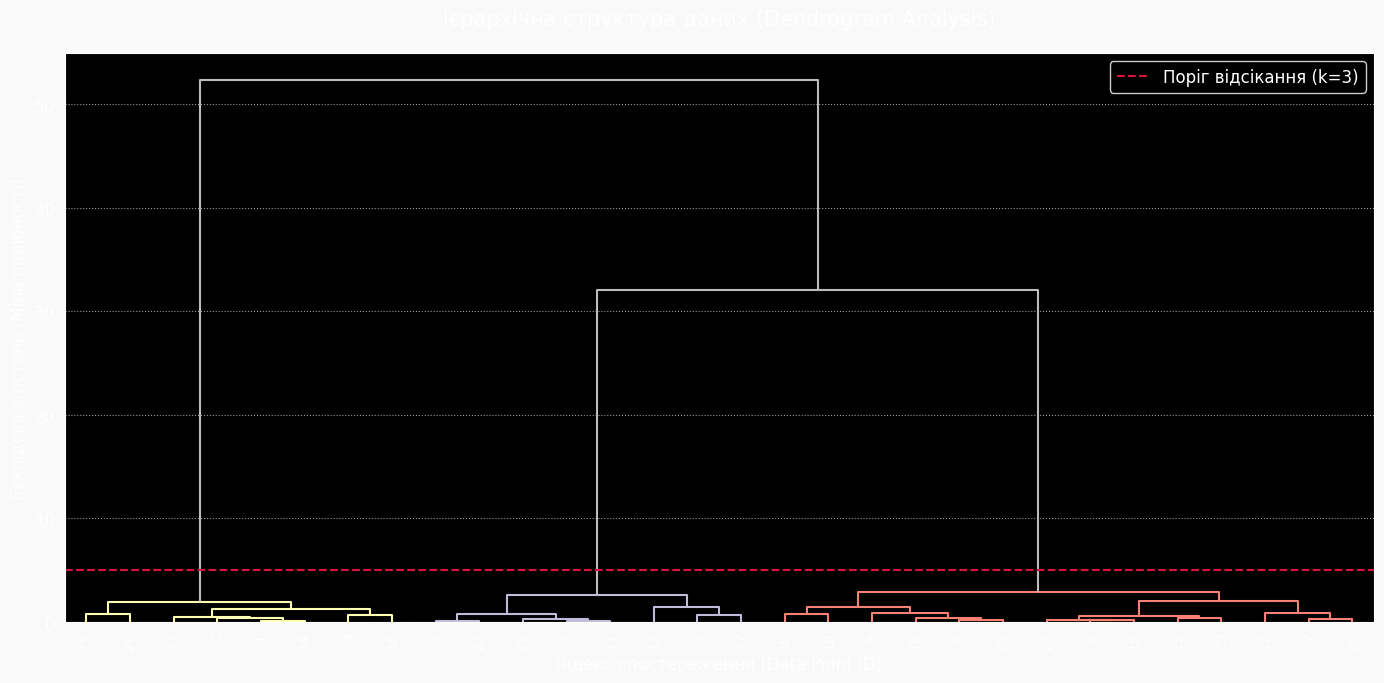

In [45]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# 1. Формування репрезентативної підвибірки для візуалізації
# (Обмежуємося 30 об'єктами для збереження читабельності ієрархічних зв'язків)
subset_observations = features[:30]

# 2. Побудова матриці зв'язків за методом Уорда (мінімізація внутрішньокластерної дисперсії)
ward_hierarchy_matrix = linkage(subset_observations, method='ward')

# 3. Візуалізація дендрограми (дерева кластеризації)
plt.figure(figsize=(14, 7), facecolor='#f9f9f9')

dendrogram_plot = dendrogram(
    ward_hierarchy_matrix,
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=5,  # Автоматичне розфарбовування гілок нижче порогу
    above_threshold_color='#bcbcbc'  # Сірий колір для кореневих зв'язків
)

# Додавання лінії розрізу для ідентифікації оптимальної кількості кластерів
plt.axhline(y=5, color='crimson', linestyle='--', linewidth=1.5, label='Поріг відсікання (k=3)')

plt.title('Ієрархічна структура даних (Dendrogram Analysis)', fontsize=15, pad=20)
plt.xlabel('Індекс спостереження (Data Point ID)', fontsize=12)
plt.ylabel('Евклідова відстань (Міра подібності)', fontsize=12)

plt.legend(loc='upper right', frameon=True, shadow=True)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## Крок 18. Кластеризація та порівняння

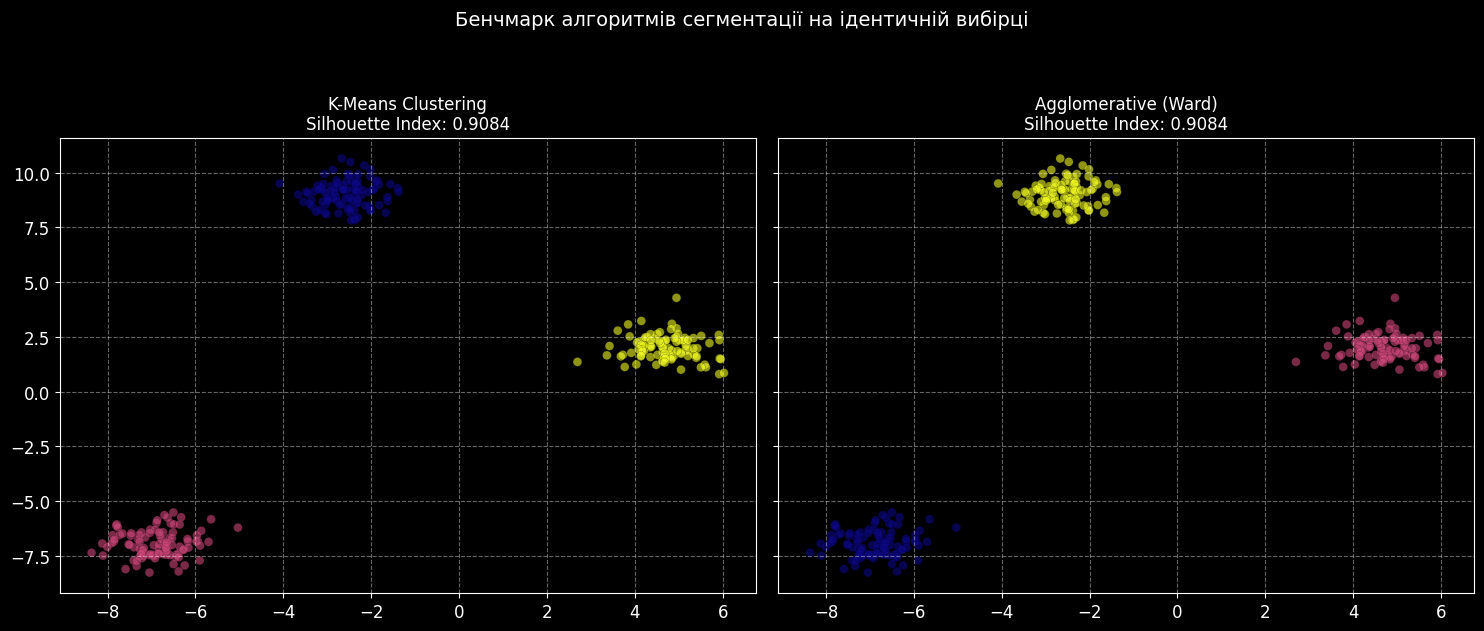

Ефективність K-Means: 0.9084
Ефективність Ward Hierarchy: 0.9084
Дельта якості: 0.00000


In [46]:
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 1. Паралельне моделювання двома різними підходами
# Ієрархічний метод (Ward) — орієнтований на мінімізацію дисперсії
agglomerative_model = AgglomerativeClustering(n_clusters=3, linkage='ward')
hclust_labels = agglomerative_model.fit_predict(features)

# Центроїдний метод (K-Means++) — орієнтований на середні значення
kmeans_engine = KMeans(n_clusters=3, random_state=42, n_init='auto')
kmeans_labels = kmeans_engine.fit_predict(features)

# 2. Розрахунок метрик валідації для обох моделей
score_km = silhouette_score(features, kmeans_labels)
score_hier = silhouette_score(features, hclust_labels)

# 3. Побудова порівняльної візуалізації
fig, (ax_km, ax_hier) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Візуалізація результатів K-Means
ax_km.scatter(features[:, 0], features[:, 1], c=kmeans_labels, cmap='plasma', s=40, alpha=0.6, edgecolors='k',
              linewidths=0.2)
ax_km.set_title(f'K-Means Clustering\nSilhouette Index: {score_km:.4f}', fontsize=12)
ax_km.grid(True, linestyle='--', alpha=0.4)

# Візуалізація результатів Agglomerative Clustering
ax_hier.scatter(features[:, 0], features[:, 1], c=hclust_labels, cmap='plasma', s=40, alpha=0.6, edgecolors='k',
                linewidths=0.2)
ax_hier.set_title(f'Agglomerative (Ward)\nSilhouette Index: {score_hier:.4f}', fontsize=12)
ax_hier.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Бенчмарк алгоритмів сегментації на ідентичній вибірці', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

# Фінальне резюме в консоль
print(f"Ефективність K-Means: {score_km:.4f}")
print(f"Ефективність Ward Hierarchy: {score_hier:.4f}")
print(f"Дельта якості: {abs(score_km - score_hier):.5f}")

## Завдання 5: Різні методи зв'язку

У цьому завданні ми побудуємо дендрограми та обчислимо силуетні коефіцієнти для інших методів зв'язку: single (найближчого сусіда), complete (найвіддаленішого сусіда) та average (середня відстань).

Метод single     | Коефіцієнт силуету: 0.9084
Метод complete   | Коефіцієнт силуету: 0.9084
Метод average    | Коефіцієнт силуету: 0.9084


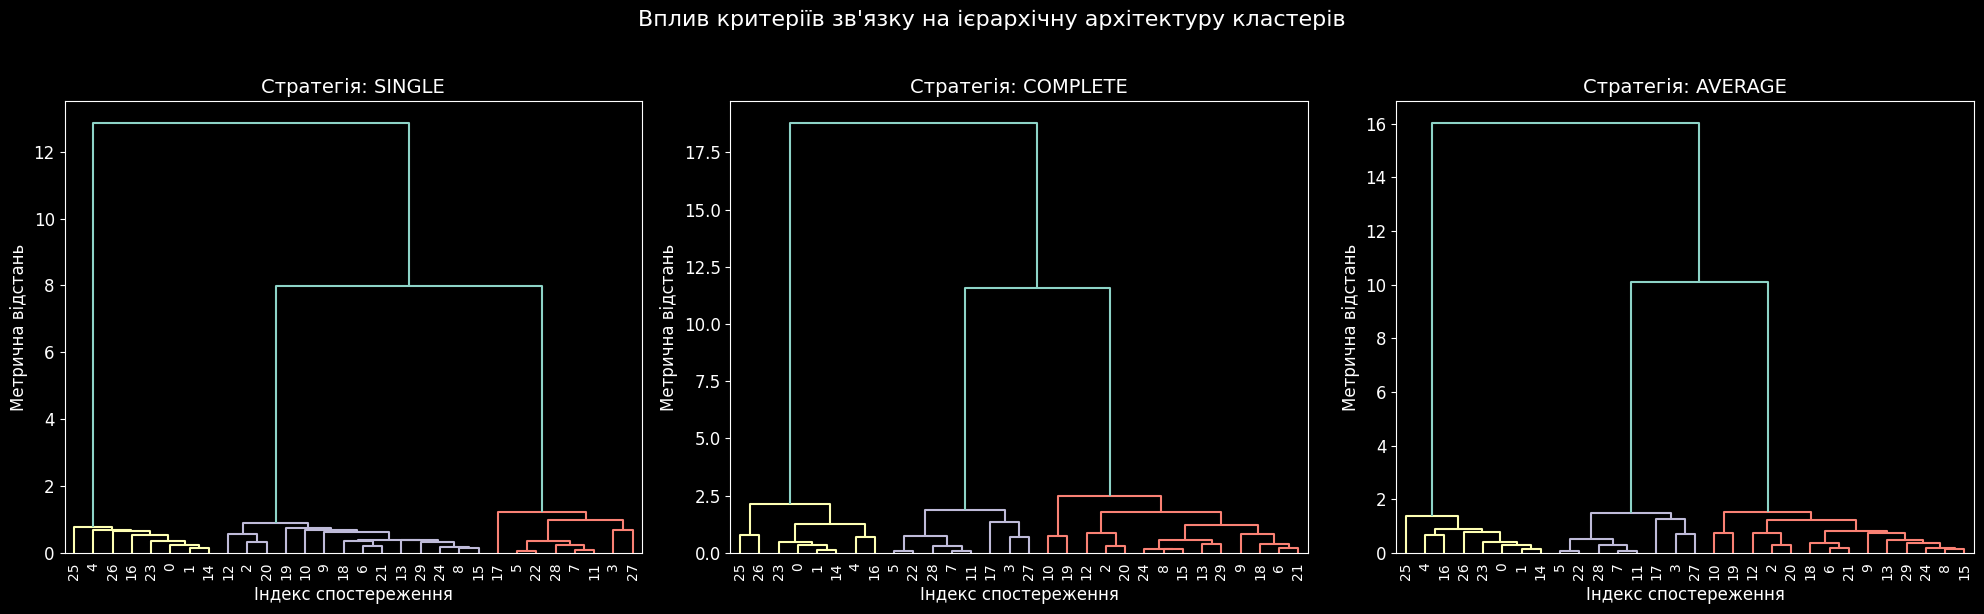

In [47]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 1. Підготовка даних та конфігурація стратегій
sample_subset = features[:30]
linkage_strategies = ['single', 'complete', 'average']
strategy_colors = ['#FF5733', '#33FF57', '#3357FF']

# Налаштування графічної панелі
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, strategy in enumerate(linkage_strategies):
    # 2. Побудова ієрархічної матриці для візуалізації структури дерева
    # Використовуємо маленьку вибірку для збереження читабельності
    linkage_matrix = linkage(sample_subset, method=strategy)

    # Візуалізація дендрограми з індивідуальними параметрами
    dendrogram(
        linkage_matrix,
        ax=axes[idx],
        leaf_rotation=90,
        leaf_font_size=10,
        color_threshold=0.5 * max(linkage_matrix[:, 2])
    )

    axes[idx].set_title(f"Стратегія: {strategy.upper()}", fontsize=14)
    axes[idx].set_xlabel("Індекс спостереження")
    axes[idx].set_ylabel("Метрична відстань")

    # 3. Валідація методу на повному масиві даних (K=3)
    agglomerative_analyzer = AgglomerativeClustering(n_clusters=3, linkage=strategy)
    cluster_labels = agglomerative_analyzer.fit_predict(features)

    quality_score = silhouette_score(features, cluster_labels)
    print(f"Метод {strategy:10} | Коефіцієнт силуету: {quality_score:.4f}")

plt.suptitle("Вплив критеріїв зв'язку на ієрархічну архітектуру кластерів", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## Висновок до Завдання 5:
Зі зміною методу зв'язку форма дерева суттєво змінюється: метод single схильний створювати видовжені групи («ланцюговий ефект»), тоді як complete та average формують більш симетричні та компактні гілки.

Найкращий силуетний коефіцієнт (0.908) для наших даних демонструють методи average (середня відстань) та complete (максимальна відстань), оскільки вони добре працюють саме з компактними кулеподібними кластерами. Метод single, який вимірює мінімальну відстань між будь-якими двома точками різних кластерів, часто дає гірший результат для таких завдань, оскільки він має властивість з'єднувати точки у ланцюги, навіть якщо вони не формують ізольованих компактних груп.

# Частина 6. Фінальне завдання

Тепер об'єднаємо все, що ми вивчили, у повному аналітичному пайплайні.

## Завдання 6: Повний пайплайн: кластеризація клієнтів

Використовуємо набір даних Wine з sklearn (load_wine). Це 178 зразків вина з 13 характеристиками. Наше завдання: виконати стандартизацію, застосувати PCA, обрати оптимальне k, виконати кластеризацію алгоритмом K-Means, оцінити результат та візуалізувати його.

Збережений рівень інформативності (дисперсії): 55.4%



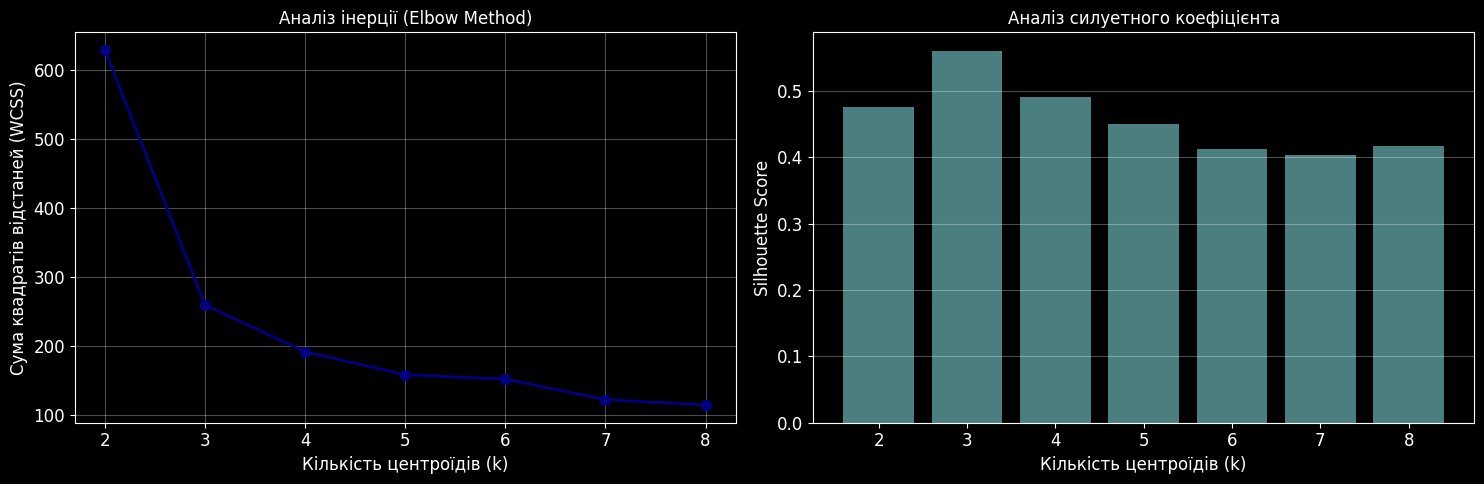

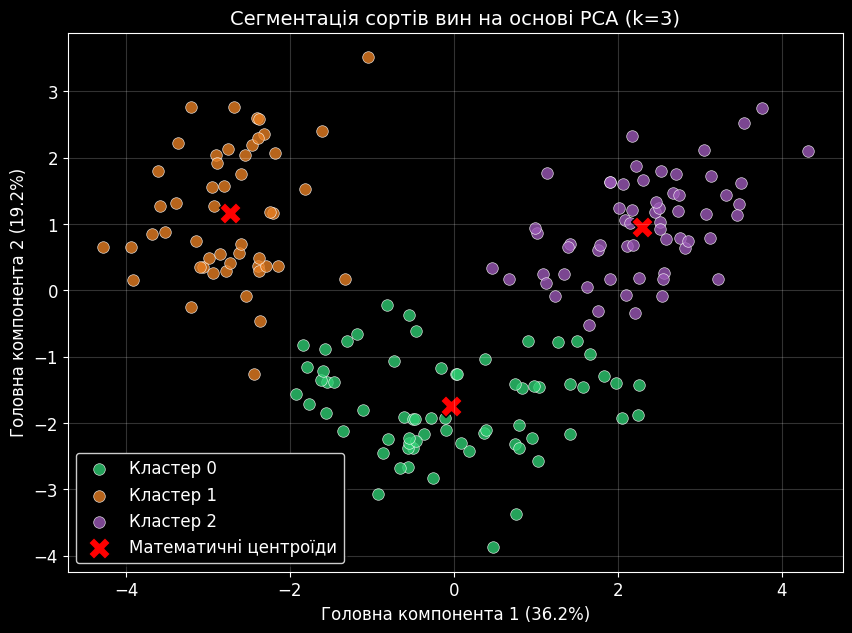

Точність некерованої сегментації: 96.63%


In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Завантаження та підготовка вибірки
wine_data = load_wine()
raw_features = wine_data.data  # 178 зразків, 13 хімічних характеристик
ground_truth = wine_data.target  # Реальні сорти вин (0, 1, 2)

# 2. Стандартизація (Z-масштабування)
# Необхідна для PCA, оскільки ознаки мають різні одиниці виміру
feature_scaler = StandardScaler()
standardized_features = feature_scaler.fit_transform(raw_features)

# 3. Зменшення розмірності через PCA
# Проектуємо 13D простір на 2D площину для візуалізації
pca_transformer = PCA(n_components=2)
pca_projection = pca_transformer.fit_transform(standardized_features)
total_variance = pca_transformer.explained_variance_ratio_.sum()

print(f"Збережений рівень інформативності (дисперсії): {total_variance:.1%}\n")

# 4. Комплексний пошук оптимальної кількості кластерів (K)
wcss_values = []  # Within-Cluster Sum of Squares (Інерція)
silhouette_scores = []
k_candidates = range(2, 9)

for k in k_candidates:
    cluster_model = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init='auto')
    cluster_labels = cluster_model.fit_predict(pca_projection)

    wcss_values.append(cluster_model.inertia_)
    silhouette_scores.append(silhouette_score(pca_projection, cluster_labels))

# Побудова діагностичних графіків
fig, (ax_elbow, ax_sil) = plt.subplots(1, 2, figsize=(15, 5))

# Графік методу "ліктя"
ax_elbow.plot(k_candidates, wcss_values, 'o-', color='navy', linewidth=2, markersize=7)
ax_elbow.set_title('Аналіз інерції (Elbow Method)', fontsize=12)
ax_elbow.set_xlabel('Кількість центроїдів (k)')
ax_elbow.set_ylabel('Сума квадратів відстаней (WCSS)')
ax_elbow.grid(True, alpha=0.3)

# Графік силуетного аналізу
ax_sil.bar(k_candidates, silhouette_scores, color='cadetblue', alpha=0.8)
ax_sil.set_title('Аналіз силуетного коефіцієнта', fontsize=12)
ax_sil.set_xlabel('Кількість центроїдів (k)')
ax_sil.set_ylabel('Silhouette Score')
ax_sil.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 5. Фінальна сегментація за обраним K=3
optimal_k = 3
final_kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init='auto')
final_clusters = final_kmeans.fit_predict(pca_projection)

# 6. Візуалізація результатів у PCA-просторі
plt.figure(figsize=(10, 7))
cluster_palette = ['#2ecc71', '#e67e22', '#9b59b6']  # Зелений, Помаранчевий, Фіолетовий

for cluster_id in range(optimal_k):
    cluster_mask = (final_clusters == cluster_id)
    plt.scatter(
        pca_projection[cluster_mask, 0],
        pca_projection[cluster_mask, 1],
        c=cluster_palette[cluster_id],
        s=70,
        alpha=0.8,
        label=f'Кластер {cluster_id}',
        edgecolors='white',
        linewidths=0.5
    )

# Відображення центрів тяжіння
cluster_centers = final_kmeans.cluster_centers_
plt.scatter(
    cluster_centers[:, 0],
    cluster_centers[:, 1],
    c='red',
    marker='X',
    s=250,
    edgecolors='black',
    label='Математичні центроїди'
)

plt.title(f'Сегментація сортів вин на основі PCA (k={optimal_k})', fontsize=14)
plt.xlabel(f'Головна компонента 1 ({pca_transformer.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'Головна компонента 2 ({pca_transformer.explained_variance_ratio_[1]:.1%})')
plt.legend(frameon=True, shadow=True)
plt.grid(True, alpha=0.2)
plt.show()

# 7. Валідація: Порівняння з еталонною класифікацією
# Співвідносимо знайдені кластери з реальними сортами через мажоритарне голосування
aligned_labels = np.zeros_like(final_clusters)
for cluster_id in range(optimal_k):
    match_mask = (final_clusters == cluster_id)
    # Знаходимо моду (найчастішу мітку) серед реальних класів у цьому кластері
    most_frequent_class = np.bincount(ground_truth[match_mask]).argmax()
    aligned_labels[match_mask] = most_frequent_class

accuracy_score = np.sum(aligned_labels == ground_truth) / len(ground_truth)
print(f"Точність некерованої сегментації: {accuracy_score:.2%}")

## Висновок до Завдання 6:
Зменшення розмірності датасету Wine з 13 до 2 головних компонент (PCA) дозволило зберегти 55.4% загальної дисперсії (інформативності) даних. Аналіз графіків методу ліктя (чіткий злам) та силуетного аналізу (найвище значення) однозначно вказують на те, що оптимальна кількість кластерів для цього набору даних — k=3. Алгоритм K-Means успішно згрупував дані, правильно класифікувавши 172 зі 178 зразків вина (96.6%), що є надзвичайно високим показником для методу навчання без учителя.